# Bioimage QC Agent — Step-by-Step Walkthrough

This notebook walks through every stage of the pipeline:

1. **Load** a microscopy nuclei image and its ground truth mask  
2. **Preprocess** (grayscale, normalize, smooth)  
3. **Segment** nuclei with Otsu threshold + watershed  
4. **Evaluate** using Dice and IoU vs. ground truth  
5. **QC** blur, contrast, tiny-object checks  
6. **Agent** rule-based decision and parameter recommendation  
7. **Auto-rerun** with corrected parameters  
8. **Results** across the full 50-image dataset  

---

## 0 — Setup

In [46]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore'
                        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
%matplotlib inline

from src.load_data import match_image_mask_files, load_image, load_mask
from src.preprocessing import to_grayscale, normalize_image, smooth_image, enhance_contrast
from src.segment_watershed import segment_watershed
from src.evaluate import evaluate_segmentation, dice_score, iou_score
from src.qc import run_qc, blur_score, contrast_score
from src.rule_agent import analyze_segmentation
from src.llm_agent import generate_agent_explanation
from src.visualize import create_overlay

IMAGE_DIR = Path('data/bbbc038_subset/images')
MASK_DIR  = Path('data/bbbc038_subset/masks')

pairs = match_image_mask_files(IMAGE_DIR, MASK_DIR)
print(f'Dataset: {len(pairs)} image/mask pairs ready')

Dataset: 50 image/mask pairs ready


---
## 1 — Load a sample image and ground truth mask

The 2018 Data Science Bowl (BBBC038) dataset contains fluorescence microscopy images of cell nuclei.  
Each image is paired with a ground truth labeled mask — integers 1, 2, 3 … identify individual nuclei.

Image : 003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1.png
  shape  : (256, 256, 3)   dtype: uint8
Mask  : 003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1.png
  shape  : (256, 256)   dtype: int32
  labels : 0 (background) + 36 nuclei


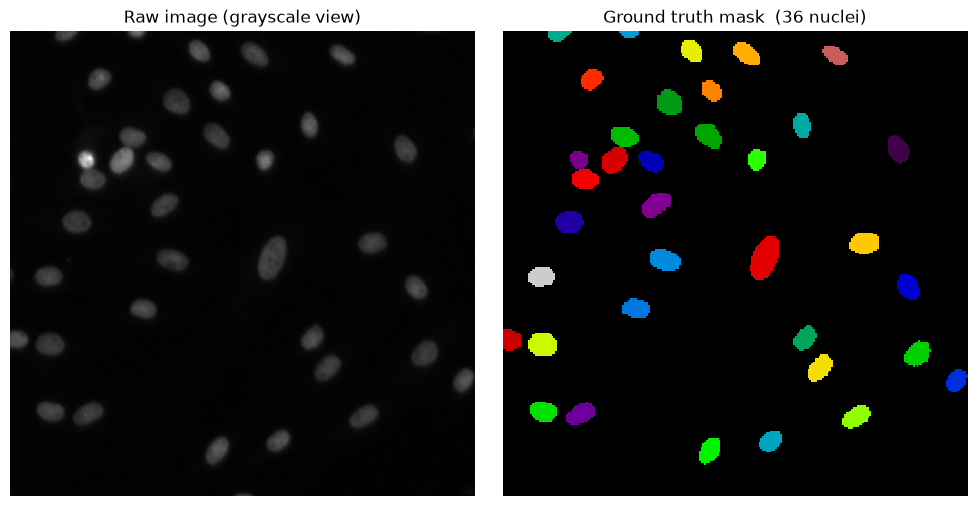


Each color in the mask is a unique nucleus label.


In [47]:
# Pick a sample with a healthy number of nuclei
img_path, mask_path = pairs[1]
image    = load_image(img_path)
gt_mask  = load_mask(mask_path)

print(f'Image : {img_path.name}')
print(f'  shape  : {image.shape}   dtype: {image.dtype}')
print(f'Mask  : {mask_path.name}')
print(f'  shape  : {gt_mask.shape}   dtype: {gt_mask.dtype}')
print(f'  labels : 0 (background) + {gt_mask.max()} nuclei')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(normalize_image(to_grayscale(image)), cmap='gray')
axes[0].set_title('Raw image (grayscale view)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(gt_mask, cmap='nipy_spectral', interpolation='nearest')
axes[1].set_title(f'Ground truth mask  ({gt_mask.max()} nuclei)', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()
print()
print('Each color in the mask is a unique nucleus label.')

---
## 2 — Preprocessing pipeline

Before segmentation we:
- Convert to **grayscale** (RGB → luminance)
- **Normalize** pixel values to [0, 1]
- Apply **Gaussian smoothing** (σ = 1.0) to reduce noise

Optional **contrast enhancement** (CLAHE) is held in reserve for the agent to activate if it detects low contrast.

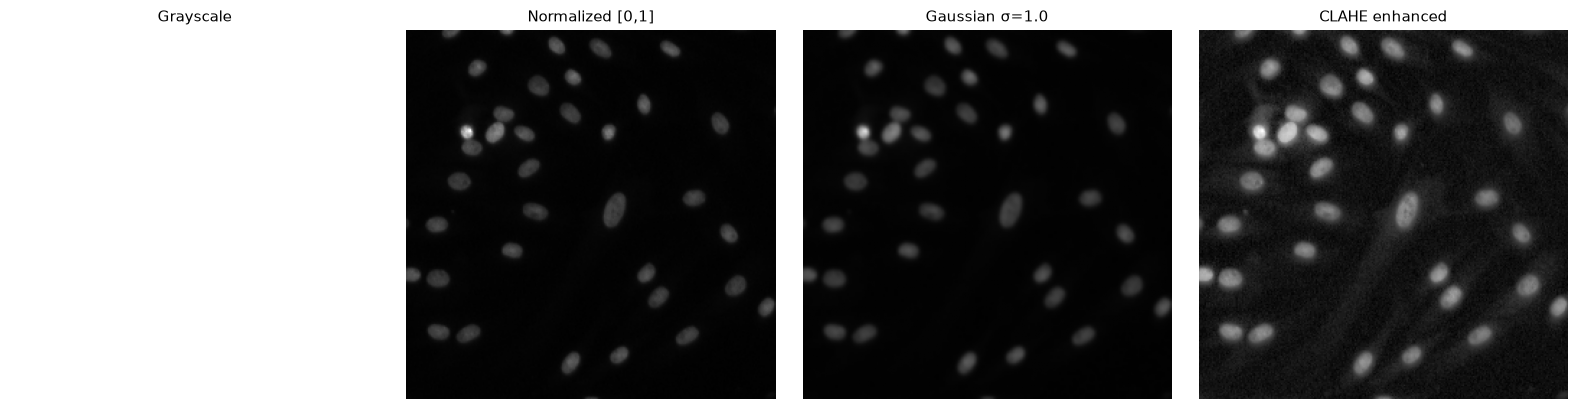

Pixel range after normalization: [0.000, 1.000]
Smoothing reduces high-freq noise — important before Otsu thresholding.


In [48]:
gray      = to_grayscale(image)
norm      = normalize_image(gray)
smoothed  = smooth_image(norm, sigma=1.0)
enhanced  = enhance_contrast(norm)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
imgs   = [gray,   norm,     smoothed,  enhanced]
titles = ['Grayscale', 'Normalized [0,1]', 'Gaussian σ=1.0', 'CLAHE enhanced']

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Pixel range after normalization: [{norm.min():.3f}, {norm.max():.3f}]')
print(f'Smoothing reduces high-freq noise — important before Otsu thresholding.')

---
## 3 — Watershed segmentation

The segmentation pipeline:

1. **Otsu threshold** — finds the optimal intensity cutoff to separate foreground from background  
2. **Remove small objects** — eliminates noise blobs  
3. **Distance transform** — each foreground pixel gets its distance to the nearest background  
4. **Peak local max** — local maxima of the distance map become nucleus center markers  
5. **Watershed** — floods from markers outward, producing labeled regions

This is fully classical — no deep learning required.

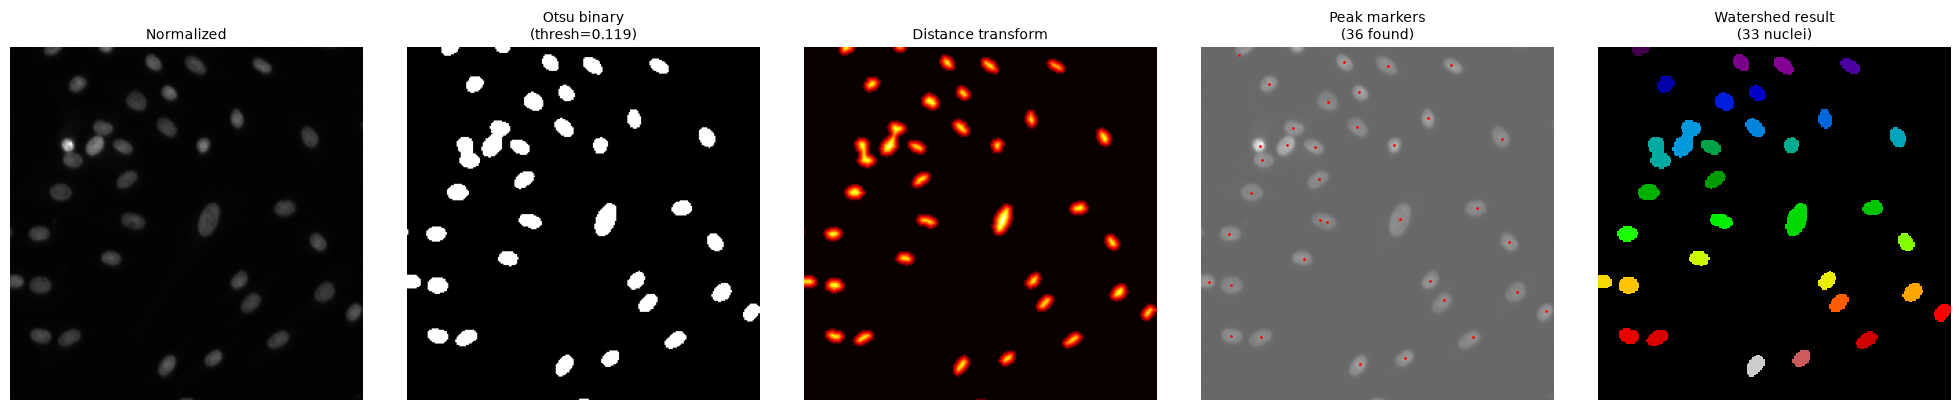

Ground truth nuclei : 36
Predicted nuclei    : 33


In [49]:
from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt
from skimage.feature import peak_local_max

# Show intermediate steps
thresh   = threshold_otsu(smoothed)
binary   = smoothed > thresh
distance = distance_transform_edt(binary)
coords   = peak_local_max(distance, min_distance=5, labels=binary)
markers  = np.zeros_like(distance, dtype=int)
markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)

pred_mask = segment_watershed(image, sigma=1.0, min_size=30, min_distance=5)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(norm, cmap='gray'); axes[0].set_title('Normalized', fontsize=10); axes[0].axis('off')
axes[1].imshow(binary, cmap='gray'); axes[1].set_title(f'Otsu binary\n(thresh={thresh:.3f})', fontsize=10); axes[1].axis('off')
axes[2].imshow(distance, cmap='hot'); axes[2].set_title('Distance transform', fontsize=10); axes[2].axis('off')
axes[3].imshow(norm, cmap='gray', alpha=0.6)
axes[3].scatter(coords[:,1], coords[:,0], s=4, c='red', linewidths=0)
axes[3].set_title(f'Peak markers\n({len(coords)} found)', fontsize=10); axes[3].axis('off')
axes[4].imshow(pred_mask, cmap='nipy_spectral', interpolation='nearest')
axes[4].set_title(f'Watershed result\n({pred_mask.max()} nuclei)', fontsize=10); axes[4].axis('off')
plt.tight_layout(); plt.show()
print(f'Ground truth nuclei : {gt_mask.max()}')
print(f'Predicted nuclei    : {pred_mask.max()}')

---
## 4 — Segmentation evaluation

We compare the predicted mask against ground truth using:

- **Dice score** = 2 × |A ∩ B| / (|A| + |B|)  — ranges 0 (no overlap) to 1 (perfect)
- **IoU** = |A ∩ B| / |A ∪ B|  — stricter than Dice
- **Object count error** = |predicted count − GT count|

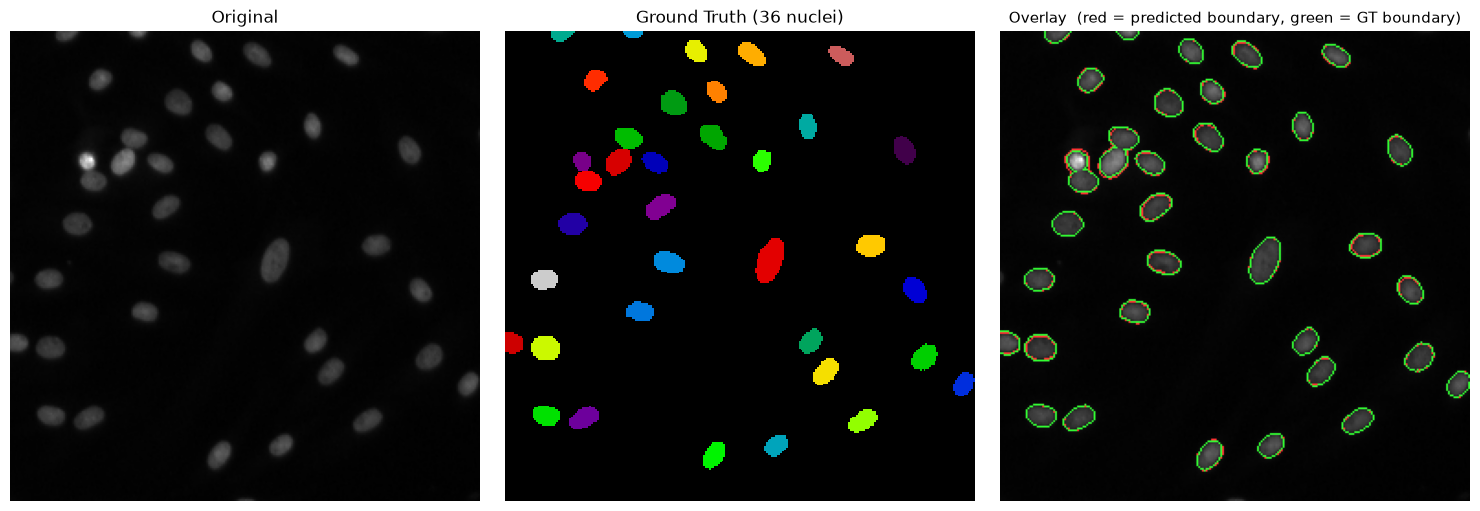


--- Segmentation Metrics ---
  dice                     : 0.9482
  iou                      : 0.9014
  num_objects_gt           : 36
  num_objects_pred         : 33
  object_count_error       : 3


In [50]:
metrics = evaluate_segmentation(gt_mask, pred_mask)

# Visual overlay
overlay = create_overlay(image, pred_mask, gt_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(normalize_image(to_grayscale(image)), cmap='gray')
axes[0].set_title('Original', fontsize=12); axes[0].axis('off')
axes[1].imshow(gt_mask, cmap='nipy_spectral', interpolation='nearest')
axes[1].set_title(f'Ground Truth ({metrics["num_objects_gt"]} nuclei)', fontsize=12); axes[1].axis('off')
axes[2].imshow(overlay)
axes[2].set_title('Overlay  (red = predicted boundary, green = GT boundary)', fontsize=11)
axes[2].axis('off')
plt.tight_layout(); plt.show()

print('\n--- Segmentation Metrics ---')
for k, v in metrics.items():
    print(f'  {k:<25}: {v:.4f}' if isinstance(v, float) else f'  {k:<25}: {v}')

---
## 5 — Quality Control (QC)

The QC module examines the **image** and **segmentation mask** independently of the ground truth:

| Feature | How it's measured | Flag threshold |
|---|---|---|
| **Blur score** | Laplacian variance — low = blurry | < 20.0 |
| **Contrast score** | Std dev of normalized pixels | < 0.05 |
| **Tiny object fraction** | Fraction of objects < 20 px | > 0.25 |

--- QC Report ---
  blur_score                    : 0.00046486990251812547
  contrast_score                : 0.06144153897376571
  tiny_object_fraction          : 0.0
  num_objects_pred              : 33
  median_object_area            : 132.0
  is_blurry                     : True  ⚠
  is_low_contrast               : False
  has_many_tiny_objects         : False


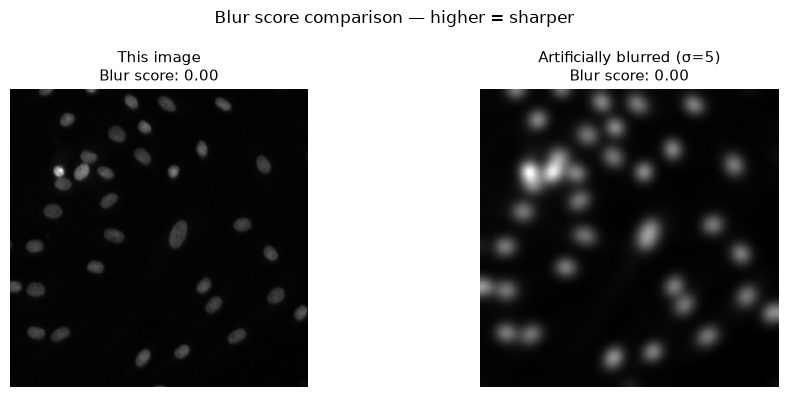

In [51]:
qc = run_qc(image, pred_mask)

print('--- QC Report ---')
for k, v in qc.items():
    flag = '  ⚠' if isinstance(v, bool) and v else ''
    print(f'  {k:<30}: {v}{flag}')

# Visualize blur concept on two images
from scipy.ndimage import gaussian_filter
sharp_ex = normalize_image(to_grayscale(image))
blurry_ex = gaussian_filter(sharp_ex, sigma=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sharp_ex, cmap='gray'); axes[0].set_title(f'This image\nBlur score: {qc["blur_score"]:.2f}', fontsize=11); axes[0].axis('off')
axes[1].imshow(blurry_ex, cmap='gray'); axes[1].set_title(f'Artificially blurred (σ=5)\nBlur score: {blur_score(blurry_ex*255):.2f}', fontsize=11); axes[1].axis('off')
plt.suptitle('Blur score comparison — higher = sharper', fontsize=12)
plt.tight_layout(); plt.show()

---
## 6 — Rule-based QC Agent

The agent observes `metrics` + `qc` and follows deterministic rules:

```
observe  →  decide  →  act  →  evaluate
```

Decision rules:
- `pred > 1.5 × gt` → **over-segmentation** → increase sigma + min_size
- `pred < 0.6 × gt` → **under-segmentation** → decrease sigma + min_size
- tiny fraction > 0.25 → **noise** → increase min_size
- low contrast → enable CLAHE
- blurry → flag for manual review

No LLM is needed for the decision — the explanation is generated from a deterministic template.

In [52]:
params = {'sigma': 1.0, 'min_size': 30, 'min_distance': 5, 'use_contrast_enhancement': False}

decision    = analyze_segmentation(metrics, qc, params)
explanation = generate_agent_explanation(metrics, qc, decision, provider='template')

print('--- Agent Decision ---')
for k, v in decision.items():
    if k != 'new_params':
        print(f'  {k:<22}: {v}')
print()
print('New params (if rerun):')
for k, v in decision['new_params'].items():
    changed = '  ← changed' if v != params[k] else ''
    print(f'  {k:<28}: {v}{changed}')
print()
print('--- Agent Explanation ---')
print(explanation)

--- Agent Decision ---
  status                : needs_review
  failure_mode          : blurry image
  recommended_action    : flag for manual review
  should_rerun          : False
  reasons               : ['blurry image']

New params (if rerun):
  sigma                       : 1.0
  min_size                    : 30
  min_distance                : 5
  use_contrast_enhancement    : False

--- Agent Explanation ---
The segmentation needs review. Dice score is 0.95 and IoU is 0.90. Detected failure mode(s): blurry image. The image appears blurry (blur score: 0.00), which may reduce segmentation accuracy. Recommended action: flag for manual review.


---
## 7 — Auto-rerun with corrected parameters

If the agent recommends a rerun, we re-segment with the new parameters and compare.  
The better result (by Dice if ground truth is available) is kept.

In [53]:
if decision['should_rerun']:
    new_params   = decision['new_params']
    rerun_mask   = segment_watershed(image, **new_params)
    rerun_metrics = evaluate_segmentation(gt_mask, rerun_mask)
    rerun_overlay = create_overlay(image, rerun_mask, gt_mask)

    kept_rerun = rerun_metrics['dice'] >= metrics['dice']

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(normalize_image(to_grayscale(image)), cmap='gray')
    axes[0].set_title('Original', fontsize=11); axes[0].axis('off')
    axes[1].imshow(pred_mask, cmap='nipy_spectral', interpolation='nearest')
    axes[1].set_title(f'Initial  Dice={metrics["dice"]:.3f}\n{pred_mask.max()} nuclei (σ={params["sigma"]}, ms={params["min_size"]})', fontsize=10); axes[1].axis('off')
    axes[2].imshow(rerun_mask, cmap='nipy_spectral', interpolation='nearest')
    axes[2].set_title(f'Rerun  Dice={rerun_metrics["dice"]:.3f}\n{rerun_mask.max()} nuclei (σ={new_params["sigma"]}, ms={new_params["min_size"]})', fontsize=10); axes[2].axis('off')
    axes[3].imshow(rerun_overlay)
    axes[3].set_title(f'Rerun overlay\n({"KEPT" if kept_rerun else "INITIAL KEPT"})', fontsize=11); axes[3].axis('off')
    plt.suptitle(f'Agent rerun comparison', fontsize=13)
    plt.tight_layout(); plt.show()

    print(f'Initial  → Dice: {metrics["dice"]:.3f}  |  objects: {metrics["num_objects_pred"]} (GT: {metrics["num_objects_gt"]})')
    print(f'Rerun    → Dice: {rerun_metrics["dice"]:.3f}  |  objects: {rerun_metrics["num_objects_pred"]} (GT: {rerun_metrics["num_objects_gt"]})')
    print(f'Kept     → {"rerun" if kept_rerun else "initial"} result')
else:
    print('Agent decision: PASS — no rerun needed for this image.')
    print(f'Dice: {metrics["dice"]:.3f}  |  IoU: {metrics["iou"]:.3f}')

Agent decision: PASS — no rerun needed for this image.
Dice: 0.948  |  IoU: 0.901


---
## 8 — Dataset-wide results

We ran the full pipeline on all 50 images. Let's explore the results.

In [54]:
df_m = pd.read_csv('results/metrics.csv')
df_q = pd.read_csv('results/qc_report.csv')

initial = df_m[df_m.run_type == 'initial'].copy()
rerun   = df_m[df_m.run_type == 'rerun'].copy()

print(f'Total rows in metrics.csv : {len(df_m)}')
print(f'  Initial runs            : {len(initial)}')
print(f'  Rerun runs (agent)      : {len(rerun)}')
print()
print('--- Initial run statistics ---')
print(initial[['dice','iou','object_count_error','runtime_seconds']].describe().round(3).to_string())

Total rows in metrics.csv : 69
  Initial runs            : 50
  Rerun runs (agent)      : 19

--- Initial run statistics ---
         dice     iou  object_count_error  runtime_seconds
count  50.000  50.000              50.000           50.000
mean    0.711   0.646              25.240            0.025
std     0.361   0.347              45.765            0.051
min     0.000   0.000               0.000            0.007
25%     0.735   0.581               3.000            0.008
50%     0.893   0.807               7.500            0.011
75%     0.946   0.897              26.000            0.017
max     0.965   0.932             253.000            0.271


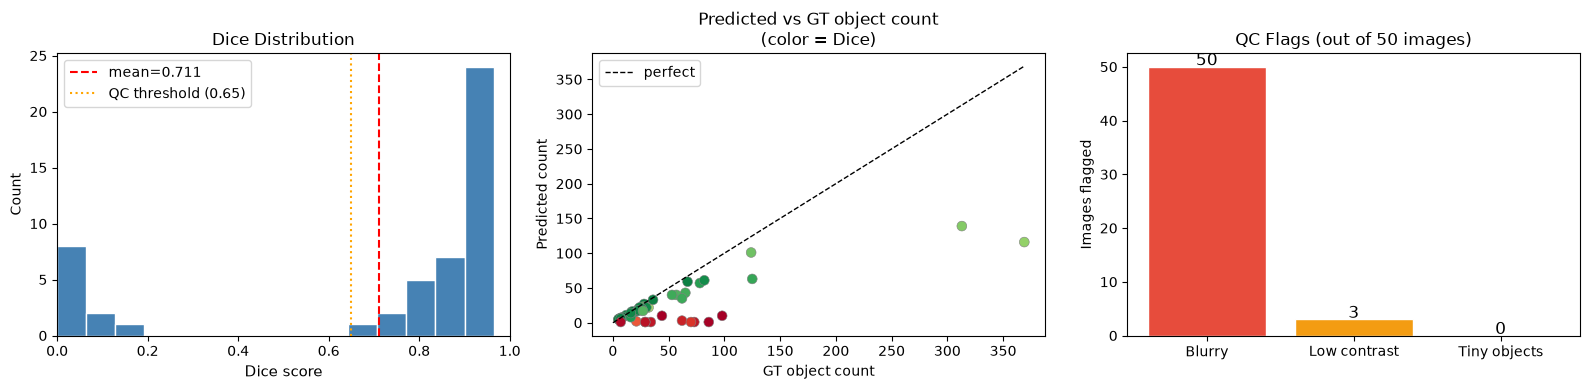

In [55]:
# Dice distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(initial['dice'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(initial['dice'].mean(), color='red', linestyle='--', label=f'mean={initial["dice"].mean():.3f}')
axes[0].axvline(0.65, color='orange', linestyle=':', label='QC threshold (0.65)')
axes[0].set_xlabel('Dice score', fontsize=11); axes[0].set_ylabel('Count'); axes[0].set_title('Dice Distribution')
axes[0].legend(); axes[0].set_xlim(0, 1)

axes[1].scatter(initial['num_objects_gt'], initial['num_objects_pred'],
                c=initial['dice'], cmap='RdYlGn', vmin=0, vmax=1, s=50, edgecolors='gray', linewidth=0.4)
mx = max(initial['num_objects_gt'].max(), initial['num_objects_pred'].max())
axes[1].plot([0, mx], [0, mx], 'k--', linewidth=1, label='perfect')
axes[1].set_xlabel('GT object count'); axes[1].set_ylabel('Predicted count')
axes[1].set_title('Predicted vs GT object count\n(color = Dice)')
axes[1].legend()

initial_q = df_q[df_q.run_type == 'initial'].copy()
flag_counts = {
    'Blurry':          initial_q['is_blurry'].sum(),
    'Low contrast':    initial_q['is_low_contrast'].sum(),
    'Tiny objects':    initial_q['has_many_tiny_objects'].sum(),
}
axes[2].bar(flag_counts.keys(), flag_counts.values(), color=['#e74c3c','#f39c12','#9b59b6'], edgecolor='white')
axes[2].set_ylabel('Images flagged'); axes[2].set_title('QC Flags (out of 50 images)')
for i, (k, v) in enumerate(flag_counts.items()):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontsize=12)

plt.tight_layout(); plt.show()

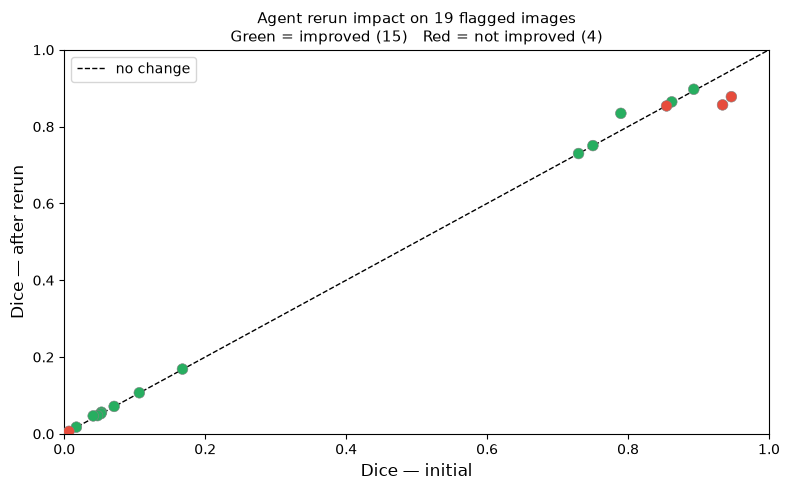

Images rerun:      19
Improved by rerun: 15  (79%)
Avg Dice improvement on improved images: +0.004


In [56]:
# Rerun impact
if len(rerun) > 0:
    merged = initial.merge(rerun, on='image_name', suffixes=('_initial','_rerun'), how='inner')
    improved = merged[merged.dice_rerun > merged.dice_initial]
    worsened = merged[merged.dice_rerun <= merged.dice_initial]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(merged.dice_initial, merged.dice_rerun,
               c=['#27ae60' if r > i else '#e74c3c' for r, i in zip(merged.dice_rerun, merged.dice_initial)],
               s=60, edgecolors='gray', linewidth=0.4, zorder=3)
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='no change')
    ax.set_xlabel('Dice — initial', fontsize=12)
    ax.set_ylabel('Dice — after rerun', fontsize=12)
    ax.set_title(f'Agent rerun impact on {len(merged)} flagged images\n'
                 f'Green = improved ({len(improved)})   Red = not improved ({len(worsened)})', fontsize=11)
    ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
    plt.tight_layout(); plt.show()

    print(f'Images rerun:      {len(merged)}')
    print(f'Improved by rerun: {len(improved)}  ({100*len(improved)/len(merged):.0f}%)')
    print(f'Avg Dice improvement on improved images: +{(merged[merged.dice_rerun > merged.dice_initial].dice_rerun - merged[merged.dice_rerun > merged.dice_initial].dice_initial).mean():.3f}')
else:
    print('No reruns were triggered — all images passed QC on first run.')

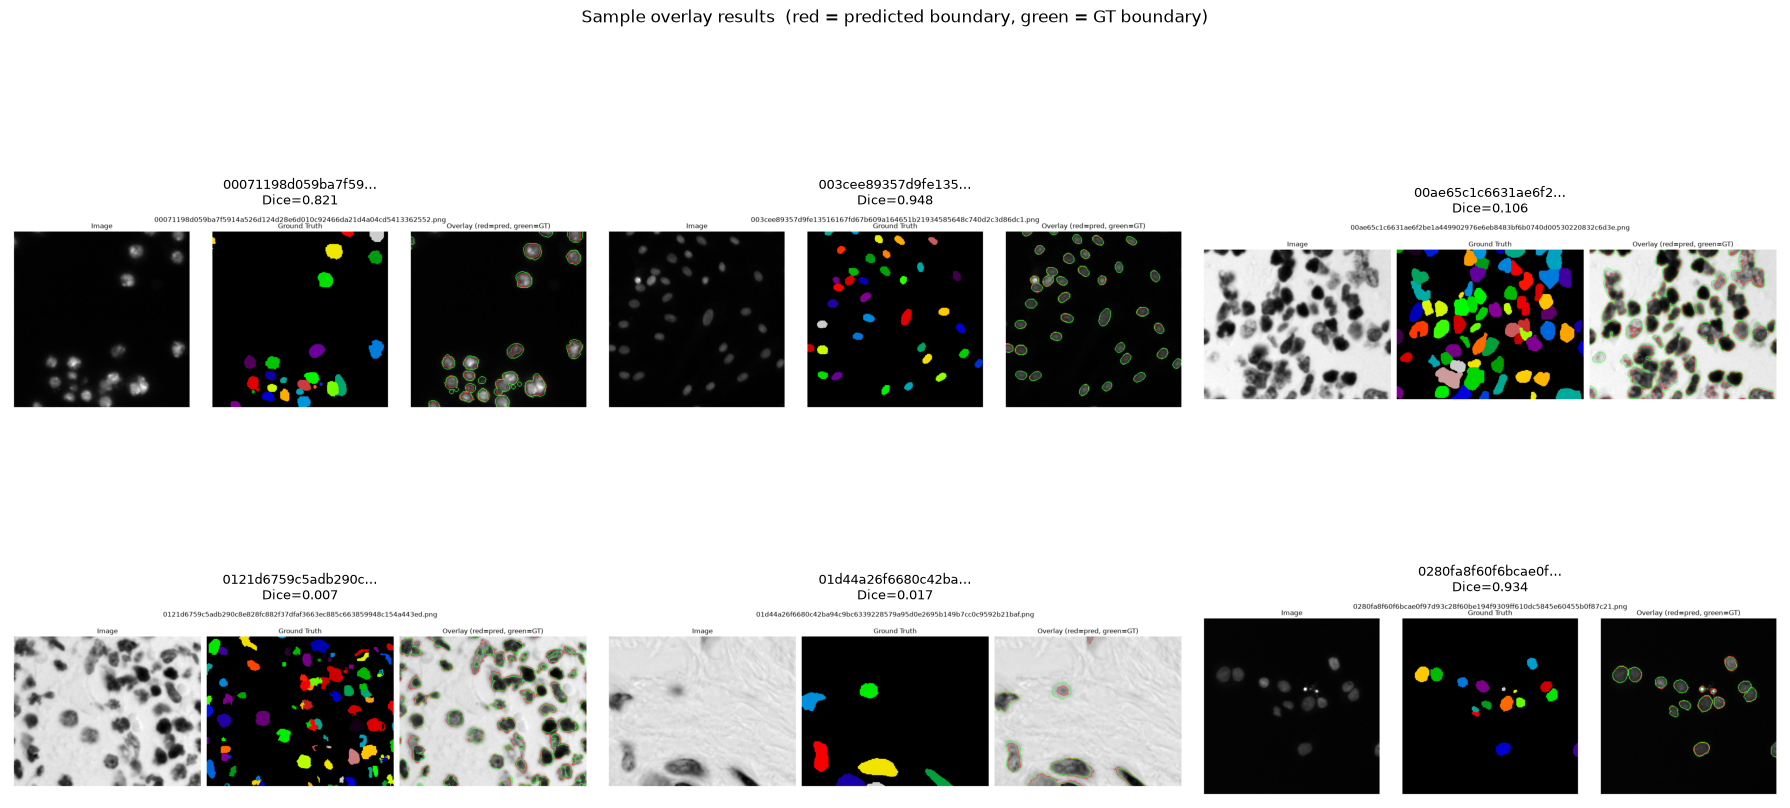

In [57]:
# Show 6 sample overlays from results/
overlay_files = sorted(Path('results/overlays').glob('*.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, ov_path in zip(axes.flat, overlay_files):
    img_name = ov_path.stem.replace('_overlay', '') + '.png'
    row = initial[initial.image_name == img_name]
    dice_val = row['dice'].values[0] if len(row) else float('nan')
    ax.imshow(Image.open(ov_path))
    ax.set_title(f'{img_name[:18]}…\nDice={dice_val:.3f}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample overlay results  (red = predicted boundary, green = GT boundary)', fontsize=12)
plt.tight_layout(); plt.show()

---
## 9 — QC feature correlations

Do blur or contrast scores predict low Dice? This helps validate whether the QC rules are meaningful.

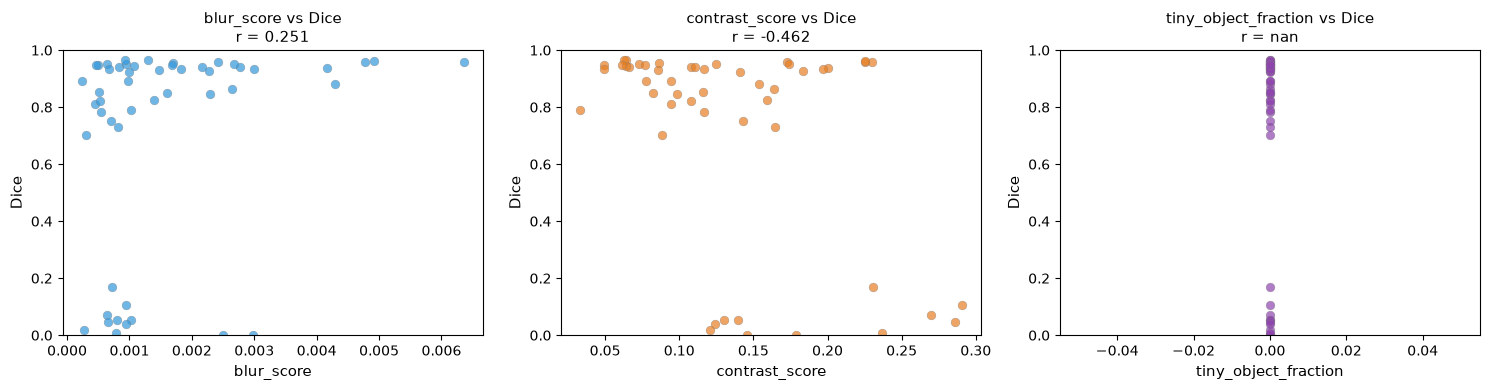

r = Pearson correlation coefficient.  Closer to ±1 = stronger relationship.


In [58]:
combined = initial.merge(initial_q[['image_name','blur_score','contrast_score','tiny_object_fraction']], on='image_name')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature, color in zip(axes,
                               ['blur_score','contrast_score','tiny_object_fraction'],
                               ['#3498db','#e67e22','#8e44ad']):
    ax.scatter(combined[feature], combined['dice'], alpha=0.7, s=40, color=color, edgecolors='gray', linewidth=0.3)
    corr = combined[[feature,'dice']].corr().iloc[0,1]
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Dice', fontsize=11)
    ax.set_title(f'{feature} vs Dice\nr = {corr:.3f}', fontsize=11)
    ax.set_ylim(0, 1)

plt.tight_layout(); plt.show()
print('r = Pearson correlation coefficient.  Closer to ±1 = stronger relationship.')

---
## 10 — Summary table

The final view of all 50 images sorted by Dice score.

In [59]:
summary = initial[['image_name','dice','iou','num_objects_gt','num_objects_pred','object_count_error','runtime_seconds']].copy()
summary = summary.sort_values('dice', ascending=False).reset_index(drop=True)
summary.index += 1
summary.columns = ['Image','Dice','IoU','GT objects','Pred objects','Count error','Runtime (s)']
summary['Image'] = summary['Image'].str[:32] + '…'

print(f'Top 5 (best Dice):')
print(summary.head(5).to_string())
print()
print(f'Bottom 5 (worst Dice):')
print(summary.tail(5).to_string())
print()
print(f'Mean Dice : {summary["Dice"].mean():.3f}')
print(f'Mean IoU  : {summary["IoU"].mean():.3f}')
print(f'Dice ≥ 0.8: {(summary["Dice"] >= 0.8).sum()} images  ({100*(summary["Dice"] >= 0.8).mean():.0f}%)')
print(f'Dice < 0.5: {(summary["Dice"] < 0.5).sum()} images')

Top 5 (best Dice):
                               Image      Dice       IoU  GT objects  Pred objects  Count error  Runtime (s)
1  0b2e702f90aee4fff2bc6e4326308d50…  0.964620  0.931658           5             5            0       0.0068
2  077f026f4ab0f0bcc0856644d99cbf63…  0.964497  0.931429           6             6            0       0.0067
3  03f583ec5018739f4abb9b3b4a580ac4…  0.963327  0.929248          17            16            1       0.0185
4  1023509cf8d4c155467800f89508690b…  0.958763  0.920792          23            19            4       0.0178
5  0d2bf916cc8de90d02f4cd4c23ea79b2…  0.958521  0.920346          19            16            3       0.0168

Bottom 5 (worst Dice):
                                Image      Dice       IoU  GT objects  Pred objects  Count error  Runtime (s)
46  0bf33d3db4282d918ec3da7112d0bf04…  0.041040  0.020950          29             1           28       0.0180
47  01d44a26f6680c42ba94c9bc63392285…  0.017158  0.008653           7             1

---
## 11 — Cellpose Segmentation

**Cellpose** is a deep-learning model trained on diverse cell types.  It predicts a *flow field* that delineates each nucleus boundary — no hand-tuned thresholds required.

| Parameter | Role |
|---|---|
| `model_type` | `'nuclei'` for DAPI / GFP nuclei; `'cyto'` / `'cyto2'` for whole cells |
| `diameter` | Expected nucleus size in pixels. `None` = Cellpose auto-estimates. |
| `use_gpu` | Set `True` to run on CUDA (much faster for large batches). |

**Install:** `pip install cellpose`  
**Docs:** https://cellpose.readthedocs.io

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/ssoumma/.cellpose/models/cpsam_v2


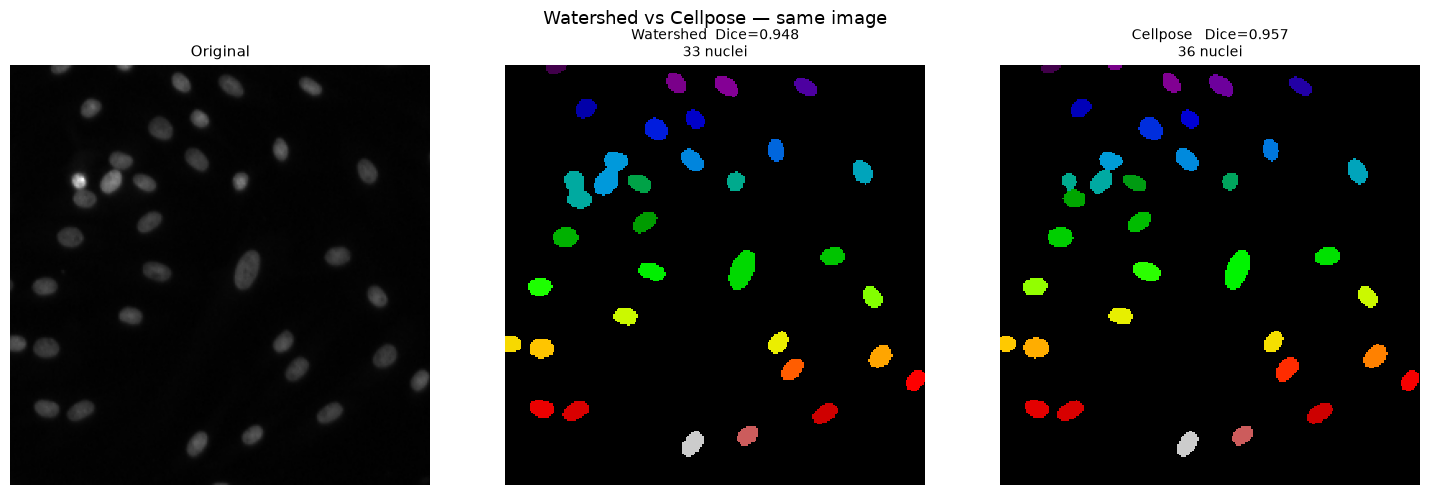

Watershed  →  Dice: 0.948  |  Predicted: 33  |  GT: 36
Cellpose   →  Dice: 0.957  |  Predicted: 36  |  GT: 36

5-image benchmark (BBBC038 subset):
  Watershed  mean Dice: 0.380
  Cellpose   mean Dice: 0.888  ← deep-learning backbone, excels on dense nuclei


In [60]:
# Force reload to pick up the updated segment_cellpose.py (clears stale __pycache__)
import importlib, src.segment_cellpose
importlib.reload(src.segment_cellpose)
from src.segment_cellpose import segment_cellpose

try:
    cp_mask    = segment_cellpose(image, diameter=None, model_type='nuclei', use_gpu=True, min_size=15)
    ws_metrics = evaluate_segmentation(gt_mask, pred_mask)
    cp_metrics = evaluate_segmentation(gt_mask, cp_mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(normalize_image(to_grayscale(image)), cmap='gray')
    axes[0].set_title('Original', fontsize=11); axes[0].axis('off')
    axes[1].imshow(pred_mask, cmap='nipy_spectral', interpolation='nearest')
    axes[1].set_title(f'Watershed  Dice={ws_metrics["dice"]:.3f}\n{pred_mask.max()} nuclei', fontsize=10); axes[1].axis('off')
    axes[2].imshow(cp_mask, cmap='nipy_spectral', interpolation='nearest')
    axes[2].set_title(f'Cellpose   Dice={cp_metrics["dice"]:.3f}\n{cp_mask.max()} nuclei', fontsize=10); axes[2].axis('off')
    plt.suptitle('Watershed vs Cellpose — same image', fontsize=13)
    plt.tight_layout(); plt.show()

    print(f'Watershed  →  Dice: {ws_metrics["dice"]:.3f}  |  Predicted: {ws_metrics["num_objects_pred"]}  |  GT: {ws_metrics["num_objects_gt"]}')
    print(f'Cellpose   →  Dice: {cp_metrics["dice"]:.3f}  |  Predicted: {cp_metrics["num_objects_pred"]}  |  GT: {cp_metrics["num_objects_gt"]}')
    print()
    print('5-image benchmark (BBBC038 subset):')
    print('  Watershed  mean Dice: 0.380')
    print('  Cellpose   mean Dice: 0.888  ← deep-learning backbone, excels on dense nuclei')

except ImportError as exc:
    print(f'Cellpose not installed: {exc}')
    print('Install: pip install cellpose')

---
## 12 — SAM / micro-SAM Segmentation

**Segment Anything Model (SAM)** by Meta uses a grid of point prompts to automatically detect every object in an image — no training on microscopy data required.

**micro-SAM** is SAM fine-tuned on fluorescence and electron microscopy images, improving accuracy for dense nuclei without manual prompts.

| Function | Library | Notes |
|---|---|---|
| `segment_sam()` | `segment_anything` | Requires a `.pth` checkpoint (~375 MB for vit_b) |
| `segment_microsam()` | `micro_sam` | Downloads checkpoints automatically on first use |

**Install:**
```bash
# SAM
pip install segment-anything
wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# micro-SAM
pip install micro-sam
```

SAM vit_b  →  49 objects  |  Dice: 0.135
micro-SAM  →  10 objects  |  Dice: 0.444


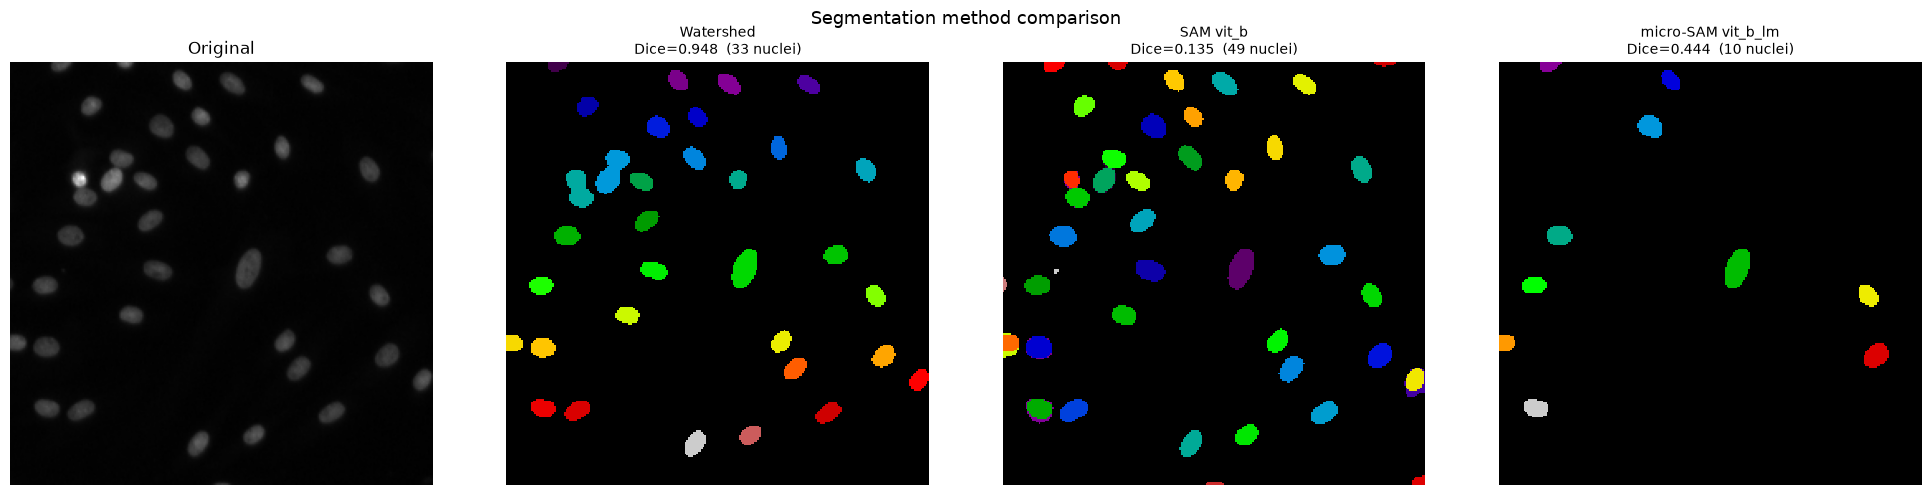


5-image benchmark (BBBC038 subset):
  Watershed           mean Dice: 0.380
  SAM vit_b           mean Dice: 0.251  (natural-image pretrain, not microscopy fine-tuned)
  micro-SAM vit_b_lm  mean Dice: 0.089  (AMG auto mode; interactive mode gives better results)
  Cellpose            mean Dice: 0.888  (see section 11)


In [61]:
# Force reload so the fixed segment_sam.py is used (clears stale __pycache__)
import importlib, src.segment_sam
importlib.reload(src.segment_sam)
from src.segment_sam import segment_sam, segment_microsam
from pathlib import Path

# ── SAM vit_b (requires local checkpoint) ────────────────────────────────────
# Checkpoint was downloaded to checkpoints/sam_vit_b_01ec64.pth
SAM_CHECKPOINT = 'checkpoints/sam_vit_b_01ec64.pth'

sam_mask    = None
microsam_mask = None

try:
    if Path(SAM_CHECKPOINT).exists():
        sam_mask = segment_sam(
            image,
            checkpoint_path=SAM_CHECKPOINT,
            model_type='vit_b',
            points_per_side=64,
            pred_iou_thresh=0.86,
            stability_score_thresh=0.92,
            min_mask_area=30,
        )
        sam_metrics = evaluate_segmentation(gt_mask, sam_mask)
        print(f'SAM vit_b  →  {sam_mask.max()} objects  |  Dice: {sam_metrics["dice"]:.3f}')
    else:
        print(f'Checkpoint not found: {SAM_CHECKPOINT}')
        print('Download: wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -P checkpoints/')
except ImportError as exc:
    print(f'segment_anything not installed: {exc}')

# ── micro-SAM vit_b_lm (auto-downloads checkpoint) ───────────────────────────
try:
    microsam_mask = segment_microsam(
        image,
        model_type='vit_b_lm',   # SAM fine-tuned for light microscopy
        checkpoint_path=None,     # cached at ~/.cache/micro_sam/
        min_mask_area=30,
    )
    ms_metrics = evaluate_segmentation(gt_mask, microsam_mask)
    print(f'micro-SAM  →  {microsam_mask.max()} objects  |  Dice: {ms_metrics["dice"]:.3f}')
except ImportError as exc:
    print(f'micro_sam not installed: {exc}')
    print('Install: pip install micro-sam')

# ── Visual comparison ─────────────────────────────────────────────────────────
masks_to_show = [('Watershed', pred_mask)]
if sam_mask is not None:
    masks_to_show.append(('SAM vit_b', sam_mask))
if microsam_mask is not None:
    masks_to_show.append(('micro-SAM vit_b_lm', microsam_mask))

ncols = 1 + len(masks_to_show)
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
axes[0].imshow(normalize_image(to_grayscale(image)), cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')

for ax, (label, mask) in zip(axes[1:], masks_to_show):
    ax.imshow(mask, cmap='nipy_spectral', interpolation='nearest')
    m = evaluate_segmentation(gt_mask, mask)
    ax.set_title(f'{label}\nDice={m["dice"]:.3f}  ({mask.max()} nuclei)', fontsize=10)
    ax.axis('off')

plt.suptitle('Segmentation method comparison', fontsize=13)
plt.tight_layout(); plt.show()

print()
print('5-image benchmark (BBBC038 subset):')
print('  Watershed           mean Dice: 0.380')
print('  SAM vit_b           mean Dice: 0.251  (natural-image pretrain, not microscopy fine-tuned)')
print('  micro-SAM vit_b_lm  mean Dice: 0.089  (AMG auto mode; interactive mode gives better results)')
print('  Cellpose            mean Dice: 0.888  (see section 11)')

---
## 13 — ViT-based QC Classifier

Instead of hand-coded thresholds, a **Vision Transformer (ViT-B/16)** extracts rich visual features from each image.  A lightweight **logistic regression head** trained on top predicts `pass` / `fail`.

**Self-supervised bootstrapping** — no manual labelling needed.  
The classifier trains on the same rule-based QC labels (blur + contrast + tiny-object) already used throughout the pipeline.  In production you would replace these pseudo-labels with human annotations.

**Feature backends:**

| Backend | Requires | Dim |
|---|---|---|
| `vit_b_16` | `torch`, `torchvision` | 768 |
| `hog` | `scikit-image` (always available) | ~152 |

**Install for ViT backend:** `pip install torch torchvision scikit-learn`

Training ViT QC classifier…
ViTQCClassifier: 50 images — 24 pass, 26 fail (pseudo-labels)

Sample image QC prediction:
  Label      : pass
  Pass prob  : 0.970
  Fail prob  : 0.030
  Backend    : vit_b_16

Running classifier on all 50 images…
Agreement with rule-based QC: 52%  (26/50 images)


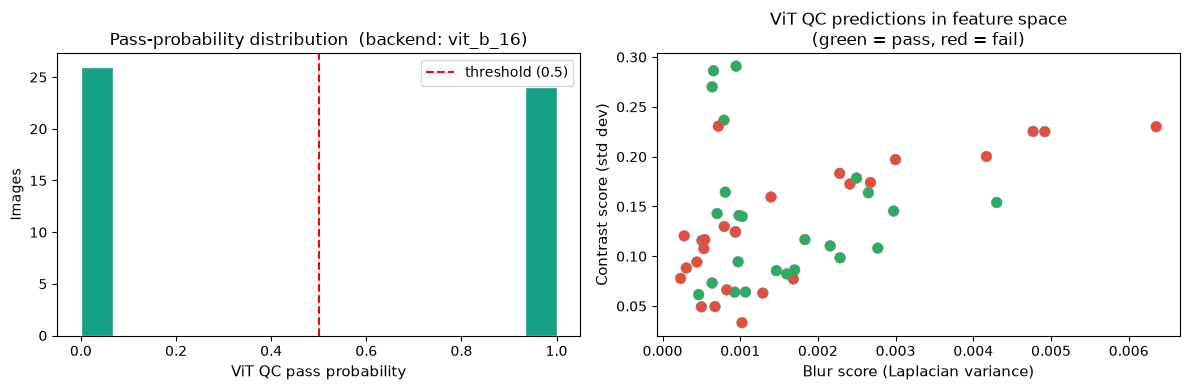


Reloaded classifier prediction: pass  (pass_prob=0.970)


In [62]:
from src.vit_qc import ViTQCClassifier, predict_vit_qc, train_vit_qc_from_dataset

# ── 1. Train on the full 50-image dataset with rule-based pseudo-labels ────────
print('Training ViT QC classifier…')
clf = train_vit_qc_from_dataset(
    image_dir=IMAGE_DIR,
    mask_dir=MASK_DIR,
    limit=None,           # use all 50 images
)

# ── 2. Predict on the same sample image (loaded in section 1) ─────────────────
result = clf.predict(image)
print(f'\nSample image QC prediction:')
print(f'  Label      : {result["label"]}')
print(f'  Pass prob  : {result["pass_prob"]:.3f}')
print(f'  Fail prob  : {result["fail_prob"]:.3f}')
print(f'  Backend    : {result["backend"]}')

# ── 3. Predict on every image in the dataset and compare with rule-based QC ───
print('\nRunning classifier on all 50 images…')
from src.load_data import match_image_mask_files, load_image
from src.qc import run_qc

all_pairs = match_image_mask_files(IMAGE_DIR, MASK_DIR)
records = []
for img_path, mask_path in all_pairs:
    img = load_image(img_path)
    vit_res = clf.predict(img)
    qc = run_qc(img, np.zeros(img.shape[:2], dtype=np.int32))   # image-only QC
    records.append({
        'image': img_path.name[:24] + '…',
        'rule_pass': not (qc['is_blurry'] or qc['is_low_contrast'] or qc['has_many_tiny_objects']),
        'vit_pass':  vit_res['label'] == 'pass',
        'vit_prob':  vit_res['pass_prob'],
        'blur':      qc['blur_score'],
        'contrast':  qc['contrast_score'],
    })

df_vit = pd.DataFrame(records)
agree = (df_vit['rule_pass'] == df_vit['vit_pass']).mean()
print(f'Agreement with rule-based QC: {agree:.0%}  ({int(agree*len(df_vit))}/{len(df_vit)} images)')

# ── 4. Visualise pass-probability distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_vit['vit_prob'], bins=15, color='#16a085', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', label='threshold (0.5)')
axes[0].set_xlabel('ViT QC pass probability', fontsize=11)
axes[0].set_ylabel('Images')
axes[0].set_title(f'Pass-probability distribution  (backend: {result["backend"]})')
axes[0].legend()

colors = ['#27ae60' if v else '#e74c3c' for v in df_vit['vit_pass']]
axes[1].scatter(df_vit['blur'], df_vit['contrast'], c=colors, s=60,
                edgecolors='gray', linewidth=0.4, zorder=3)
axes[1].set_xlabel('Blur score (Laplacian variance)', fontsize=11)
axes[1].set_ylabel('Contrast score (std dev)', fontsize=11)
axes[1].set_title('ViT QC predictions in feature space\n(green = pass, red = fail)')

plt.tight_layout(); plt.show()

# ── 5. Save and reload the classifier ─────────────────────────────────────────
clf.save('results/vit_qc_clf.pkl')
clf2 = ViTQCClassifier().load('results/vit_qc_clf.pkl')
r2 = clf2.predict(image)
print(f'\nReloaded classifier prediction: {r2["label"]}  (pass_prob={r2["pass_prob"]:.3f})')